Generate fake data


In [1]:
import numpy as np

#Define the number of data points
n_points = 1000

#Generate a time array
time = np.linspace(0, 100, n_points)

#Create a sine wave
amplitude = 10
frequency = 0.1
sine_wave = amplitude * np.sin(frequency * time)

#Generate random noise
noise_std_dev = 2
noise = np.random.randn(n_points) * noise_std_dev

#Combine the sine wave and the noise
synthetic_time_series = sine_wave + noise

#Store the generated time series data (already stored in numpy array)

print("Generated synthetic time series data (first 10 points):\n", synthetic_time_series[:10])

Generated synthetic time series data (first 10 points):
 [ 0.38684353  1.24177224 -3.16642869  1.11087863 -0.90067589  0.90617958
 -1.10464958  2.05166045  3.65974762  3.44427802]


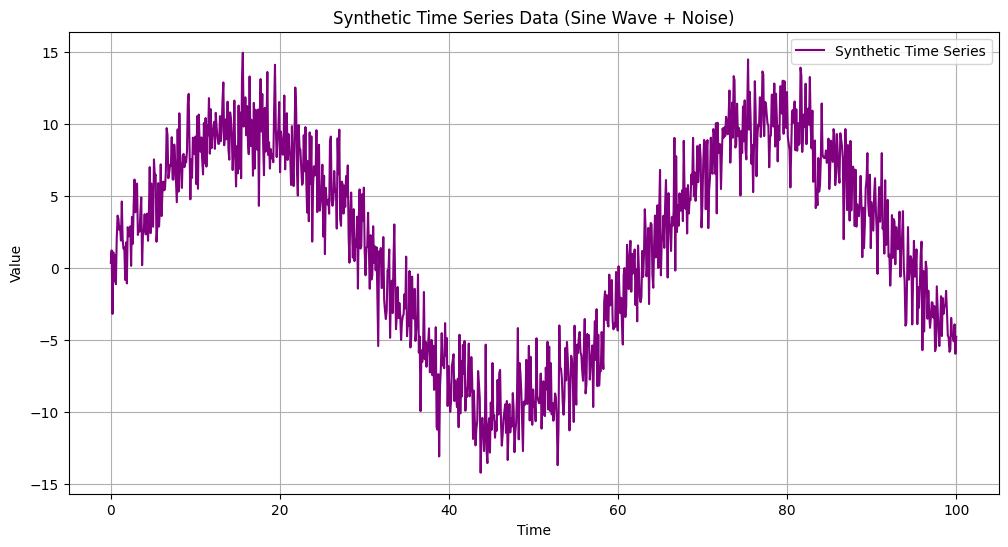

In [2]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))
plt.plot(time, synthetic_time_series, label='Synthetic Time Series', color='purple')
plt.title('Synthetic Time Series Data (Sine Wave + Noise)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

Prepare proper timeseries training set



In [3]:
import torch

#Define a look_back window size
look_back = 20

#Prepare empty lists to store sequences
X = []
y = []

#Create input-output pairs
for i in range(len(synthetic_time_series) - look_back):
    # 3. Input sequence (X) and target value (y)
    feature_sequence = synthetic_time_series[i:(i + look_back)]
    target_value = synthetic_time_series[i + look_back]
    X.append(feature_sequence)
    y.append(target_value)

#Convert lists to numpy arrays
X = np.array(X)
y = np.array(y)

print(f"Shape of X (input sequences): {X.shape}")
print(f"Shape of y (target values): {y.shape}")
print("First 5 input sequences:\n", X[:5])
print("First 5 target values:\n", y[:5])

Shape of X (input sequences): (980, 20)
Shape of y (target values): (980,)
First 5 input sequences:
 [[ 0.38684353  1.24177224 -3.16642869  1.11087863 -0.90067589  0.90617958
  -1.10464958  2.05166045  3.65974762  3.44427802  2.66387172  2.89279862
   1.92234438  4.63857787  2.02562049  1.36073339  1.45583932 -0.80987383
   1.79565092 -1.05050336]
 [ 1.24177224 -3.16642869  1.11087863 -0.90067589  0.90617958 -1.10464958
   2.05166045  3.65974762  3.44427802  2.66387172  2.89279862  1.92234438
   4.63857787  2.02562049  1.36073339  1.45583932 -0.80987383  1.79565092
  -1.05050336  2.85520291]
 [-3.16642869  1.11087863 -0.90067589  0.90617958 -1.10464958  2.05166045
   3.65974762  3.44427802  2.66387172  2.89279862  1.92234438  4.63857787
   2.02562049  1.36073339  1.45583932 -0.80987383  1.79565092 -1.05050336
   2.85520291  2.22241141]
 [ 1.11087863 -0.90067589  0.90617958 -1.10464958  2.05166045  3.65974762
   3.44427802  2.66387172  2.89279862  1.92234438  4.63857787  2.02562049
   1

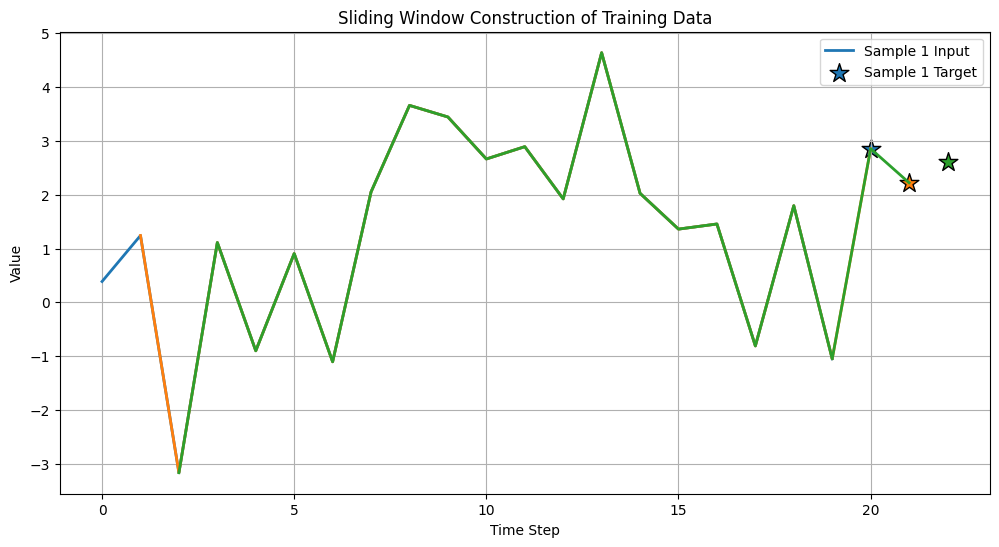

In [4]:
import matplotlib.pyplot as plt
import numpy as np

#Number of examples to visualize
num_examples = 3

plt.figure(figsize=(12, 6))

for i in range(num_examples):
    input_sequence = X[i]
    target_value = y[i]

    #X-axis positions
    input_timesteps = np.arange(i, i + look_back)
    target_timestep = i + look_back


    base_color = f"C{i}"

    #Plot input sequence
    plt.plot(
        input_timesteps,
        input_sequence,
        color=base_color,
        linestyle='-',
        linewidth=2,
        label=f"Sample {i+1} Input" if i == 0 else None
    )

    #Plot target point
    plt.scatter(
        target_timestep,
        target_value,
        color=base_color,
        marker='*',
        s=200,
        edgecolor='black',
        label=f"Sample {i+1} Target" if i == 0 else None
    )

plt.title("Sliding Window Construction of Training Data")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.show()

Build the RNN


In [5]:
import torch
import torch.nn as nn

#Convert NumPy arrays to PyTorch tensors and reshape X
#Ensure X has shape (batch_size, sequence_length, input_size)
#For univariate time series, input_size is 1
X_tensor = torch.from_numpy(X).float().unsqueeze(-1) #Add a feature dimension
y_tensor = torch.from_numpy(y).float()

print(f"Shape of X_tensor: {X_tensor.shape}")
print(f"Shape of y_tensor: {y_tensor.shape}")

#Split data into training and testing sets
train_size = int(0.8 * len(X_tensor))
X_train, X_test = X_tensor[:train_size], X_tensor[train_size:]
y_train, y_test = y_tensor[:train_size], y_tensor[train_size:]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")


class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size

        #Define the rNN layer and a linear layer
        #batch_first=True means input/output tensors are (batch_size, seq_len, features)
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    # 5. Define the forward pass
    def forward(self, x):
        #Initialize hidden state with zeros
        #(num_layers * num_directions, batch_size, hidden_size)
        h0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)

        #Forward propagate RNN
        out, _ = self.rnn(x, h0)

        #Pass the output of the last time step to the linear layer
        #out[:, -1, :] takes the hidden state of the last time step
        out = self.fc(out[:, -1, :])

        #Another option
        #out, hnn = self.rnn(x)
        #logits = self.fc(hn[-1])
        return out

print("RNNModel class defined successfully.")

Shape of X_tensor: torch.Size([980, 20, 1])
Shape of y_tensor: torch.Size([980])
Shape of X_train: torch.Size([784, 20, 1])
Shape of y_train: torch.Size([784])
Shape of X_test: torch.Size([196, 20, 1])
Shape of y_test: torch.Size([196])
RNNModel class defined successfully.


Train the RNN Model

In [6]:
import torch.optim as optim

#Instantiate the RNNModel
input_size = 1
hidden_size = 50
output_size = 1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RNNModel(input_size, hidden_size, output_size).to(device)

#Define loss function and optimizer
criterion = nn.MSELoss() # Mean Squared Error Loss
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimizer with a learning rate of 0.001

#Define number of training epochs
num_epochs = 100

#Move data to the same device as the model
X_train = X_train.to(device)
y_train = y_train.to(device)

#Create a training loop
print("Starting RNN model training...")
for epoch in range(num_epochs):
    #Forward pass
    model.train() #Set model to train mode
    outputs = model(X_train)

    #Reshape outputs to match y_train shape if necessary
    #outputs.squeeze() handles cases where output is (batch_size, 1) and y_train is (batch_size)
    loss = criterion(outputs.squeeze(), y_train)

    #Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #Print loss every few epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

print("RNN model training complete.")

Starting RNN model training...
Epoch [10/100], Loss: 45.0389
Epoch [20/100], Loss: 34.0290
Epoch [30/100], Loss: 25.4087
Epoch [40/100], Loss: 19.6718
Epoch [50/100], Loss: 16.4224
Epoch [60/100], Loss: 14.1915
Epoch [70/100], Loss: 12.4400
Epoch [80/100], Loss: 11.1362
Epoch [90/100], Loss: 10.0629
Epoch [100/100], Loss: 9.2239
RNN model training complete.


Prediction evaluation



Test Loss: 7.4143


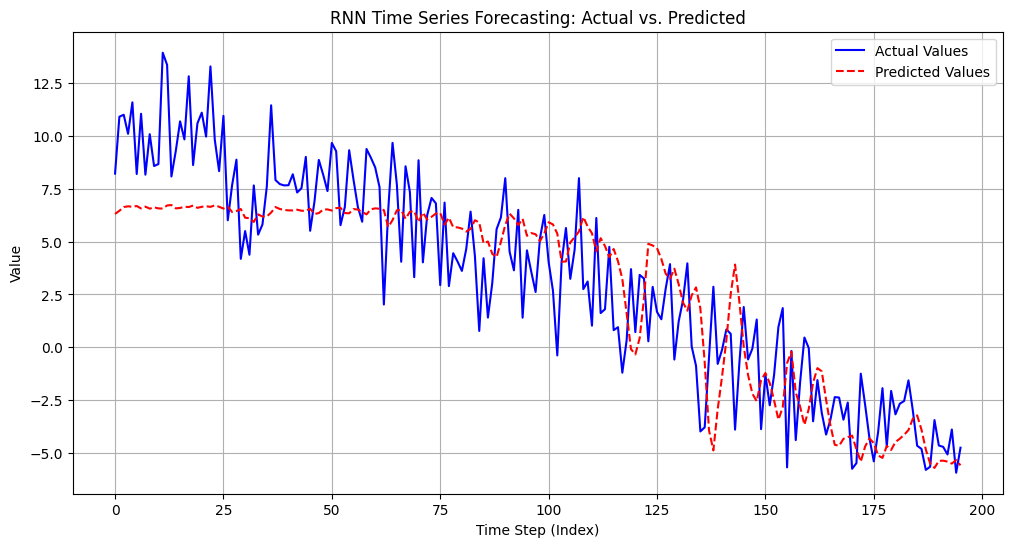

In [7]:
import matplotlib.pyplot as plt

#Move test data to the same device as the model
X_test = X_test.to(device)
y_test = y_test.to(device)

#Evaluate the model on the test set
model.eval() #Set the model to evaluation mode
with torch.no_grad(): #Disable gradient calculation for evaluation
    test_predictions = model(X_test)
    test_loss = criterion(test_predictions.squeeze(), y_test)

print(f'Test Loss: {test_loss.item():.4f}')

#Visualize predictions against actual values
#Move data back to CPU for plotting
predictions_np = test_predictions.cpu().numpy().squeeze()
actual_np = y_test.cpu().numpy()

plt.figure(figsize=(12, 6))
plt.plot(actual_np, label='Actual Values', color='blue')
plt.plot(predictions_np, label='Predicted Values', color='red', linestyle='--')
plt.title('RNN Time Series Forecasting: Actual vs. Predicted')
plt.xlabel('Time Step (Index)')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()
